In [1]:
from sklearn.linear_model import Lasso
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

[28.38856939]
-2.66908963192478


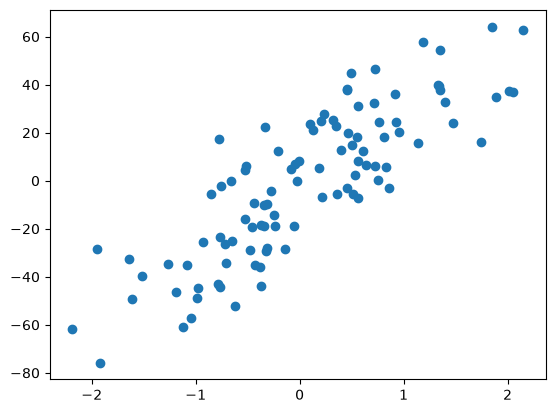

In [2]:
X,Y = make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20,random_state=13)
X_train,X_test,Y_train,Y_test = train(X,Y,0.2)
plt.scatter(X,Y)
lr = LinearRegression()
lr.fit(X_train,Y_train)
print(lr.coef_)
print(lr.intercept_)

C:\Users\Anjli Kumari\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\base.py:1403: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)


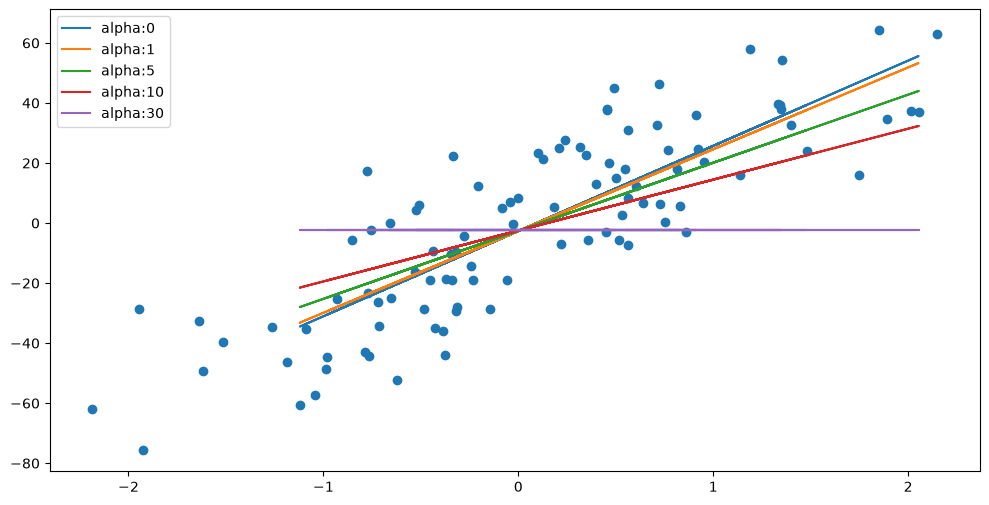

In [3]:
alphas = [0,1,5,10,30]
plt.figure(figsize=(12,6))
plt.scatter(X,Y)
for i in alphas:
    ls = Lasso(alpha=i)
    ls.fit(X_train,Y_train)
    plt.plot(X_test,ls.predict(X_test),label='alpha:{}'.format(i))
plt.legend()
plt.show()

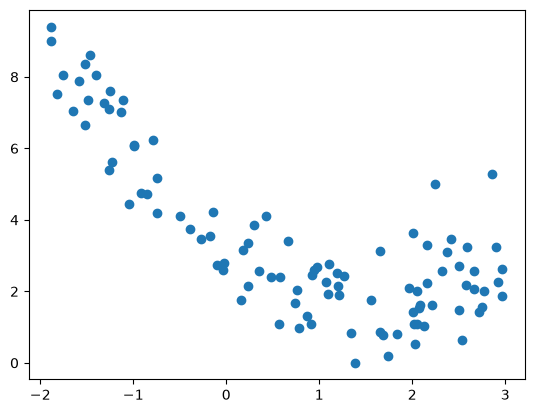

In [4]:
m = 100
x1 = 5 * np.random.rand(m,1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m,1)
plt.scatter(x1,x2)
plt.show()

C:\Users\Anjli Kumari\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\base.py:1403: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\Users\Anjli Kumari\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.055697e+08, tolerance: 5.316e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
C:\Users\Anjli Kumari\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might w

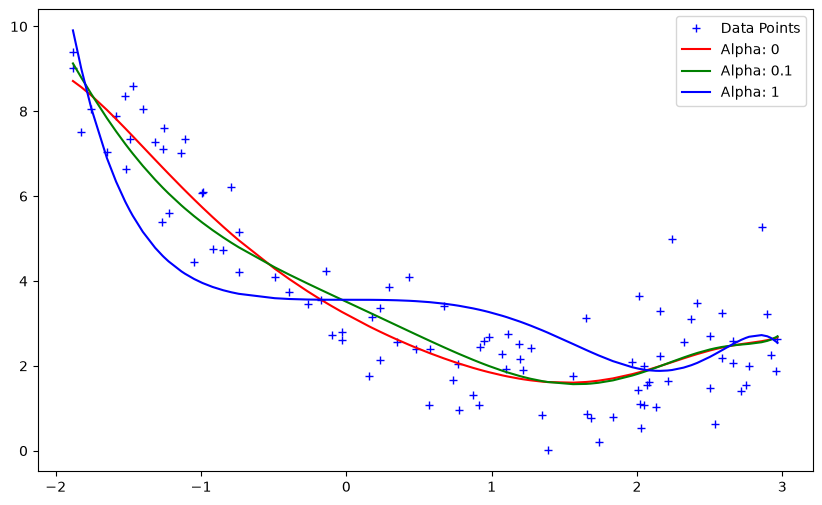

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge,Lasso

def get_preds_lasso(x1,x2,alpha):
    model = Pipeline([
        ('poly_feats',PolynomialFeatures(degree=16)),
        ('lasso',Lasso(alpha=alpha))
    ])
    model.fit(x1,x2)
    return model.predict(x1)

alphas = [0,0.1,1]
cs = ['r','g','b']
plt.figure(figsize=(10,6))
plt.plot(x1,x2,'b+',label='Data Points')
for alpha,c in zip(alphas,cs):
    preds = get_preds_lasso(x1,x2,alpha)
    plt.plot(sorted(x1[:,0]),preds[np.argsort(x1[:,0])],c,label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()

### Key Points About Lasso Regression

In [2]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

In [2]:
data = load_diabetes()
df = pd.DataFrame(data.data,columns = data.feature_names)
df['Target'] = data.target
data_info(df)

Shape:(442, 11),
Null Values: 
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
Target    0
dtype: int64

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  Target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB
Data Description:                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
X_train,X_test,Y_train,Y_test = train(data.data,data.target,0.2,2)

#### Q1. How Are Coefficients Affected?

In [10]:
coefs = []
r2_scores = []
for i in [0,0.1,1,10]:
    if i == 0:
        reg = LinearRegression()
    else:
        reg = Lasso(alpha=i)
    reg.fit(X_train,Y_train)
    coefs.append(reg.coef_.tolist())
    Y_pred = reg.predict(X_test)
    r2_scores.append(r2_score(Y_test,Y_pred))

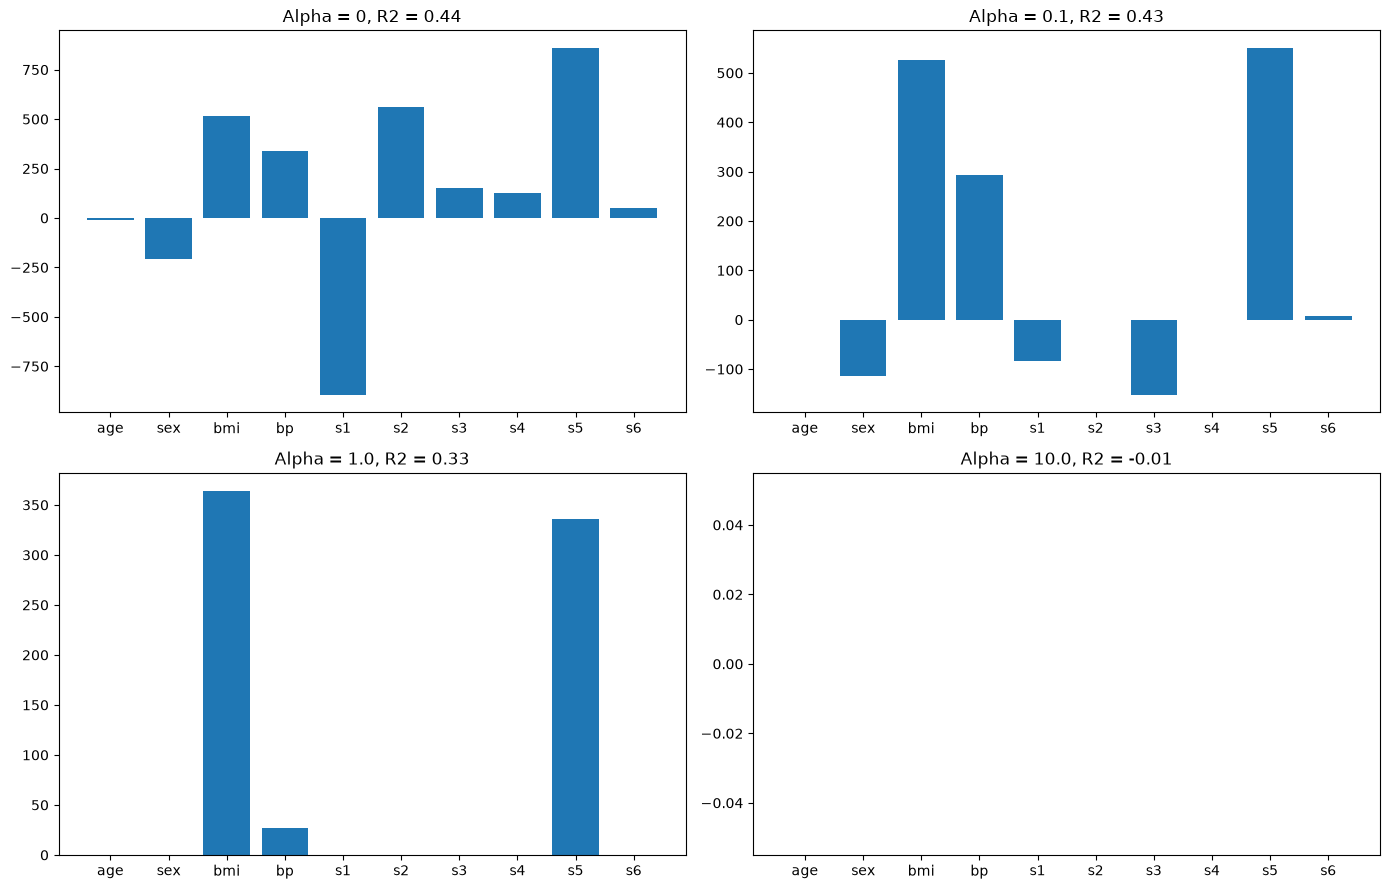

In [11]:
plt.figure(figsize=(14, 9))
plt.subplot(221)
plt.bar(data.feature_names, coefs[0])
plt.title('Alpha = 0, R2 = {}'.format(round(r2_scores[0], 2)))
plt.subplot(222)
plt.bar(data.feature_names, coefs[1])
plt.title('Alpha = 0.1, R2 = {}'.format(round(r2_scores[1], 2)))
plt.subplot(223)
plt.bar(data.feature_names, coefs[2])
plt.title('Alpha = 1.0, R2 = {}'.format(round(r2_scores[2], 2)))
plt.subplot(224)
plt.bar(data.feature_names, coefs[3])   # FIXED
plt.title('Alpha = 10.0, R2 = {}'.format(round(r2_scores[3], 2)))
plt.tight_layout()
plt.show()

#### Q2.Higher Coefficients Are Affected  By How Much??

In [13]:
alphas = [0,0.0001,0.001,0.01,0.1,1,10,100,1000,10000]
coefs = []

for i in alphas:
    if i == 0:
        reg = LinearRegression()
    else:
        reg = Lasso(alpha=i)
    reg.fit(X_train,Y_train)
    coefs.append(reg.coef_.tolist())

In [14]:
inp_arr = np.array(coefs)
coef_df = pd.DataFrame(inp_arr,columns=data.feature_names)
coef_df['alpha'] = alphas
coef_df.set_index('alpha')

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
alpha,,,,,,,,,,
0.0000,-9.158653,-205.454322,516.693745,340.619999,-895.552002,561.220679,153.893110,126.731397,861.127002,52.421122
0.0001,-9.069064,-205.329406,516.789418,340.532379,-888.660904,555.958584,150.593655,125.450143,858.645541,52.380294
0.0010,-8.262770,-204.205364,517.650073,339.743901,-826.663603,508.617395,120.908607,113.921773,836.320753,52.012849
0.0100,-1.359721,-192.937180,526.356514,332.641101,-430.226975,191.295480,-44.034913,68.988987,688.396028,47.940616
0.1000,0.000000,-113.969928,526.744396,292.628472,-82.693681,-0.000000,-152.685338,0.000000,551.080291,7.170992
1.0000,0.000000,0.000000,363.885742,27.273163,0.000000,0.000000,-0.000000,0.000000,336.137262,0.000000
10.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
100.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1000.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [19]:
alphas_1 = [0,0.0001,0.0005,0.001,0.005,0.1,0.5,1,5,10]
coefs_1 = []

for i in alphas_1:
    if i == 0:
        reg = LinearRegression()
    else:
        reg = Lasso(alpha=i)
    reg.fit(X_train,Y_train)
    coefs_1.append(reg.coef_.tolist())

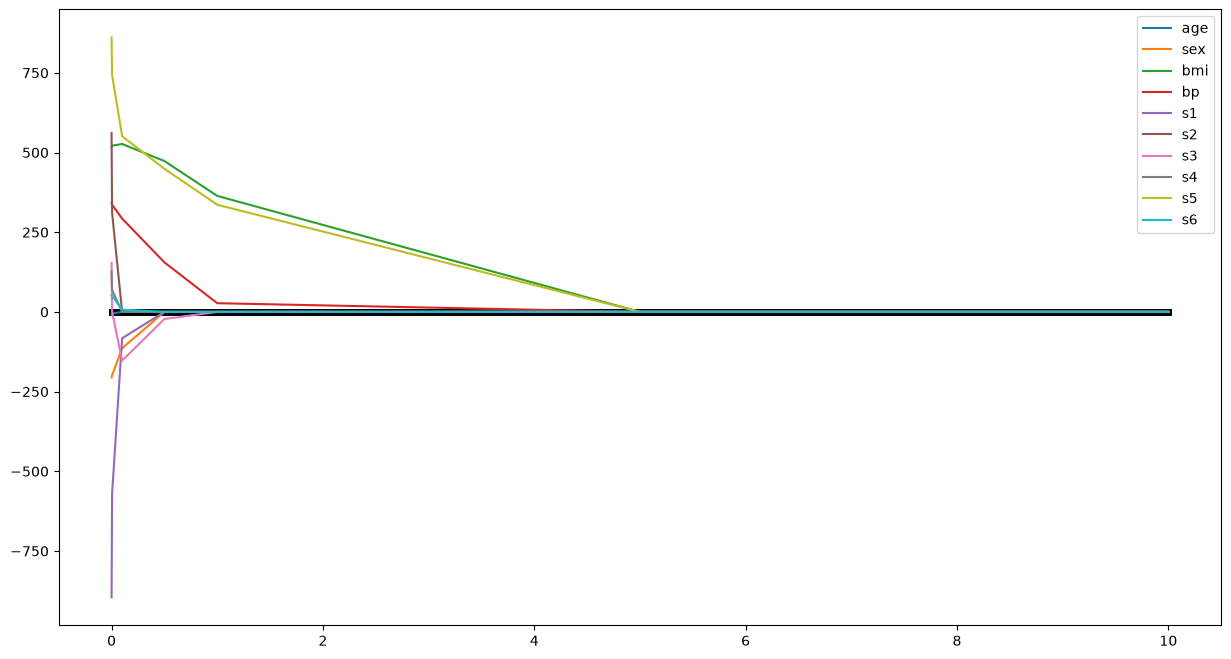

In [21]:
inp_arr_1 = np.array(coefs_1).T
plt.figure(figsize=(15,8))
plt.plot(alphas_1,np.zeros(len(alphas_1)),color='black',linewidth=5)
for i in range(inp_arr_1.shape[0]):
    plt.plot(alphas_1,inp_arr_1[i],label=data.feature_names[i])
plt.legend()

#### Q3.Impact On Bias And Variance

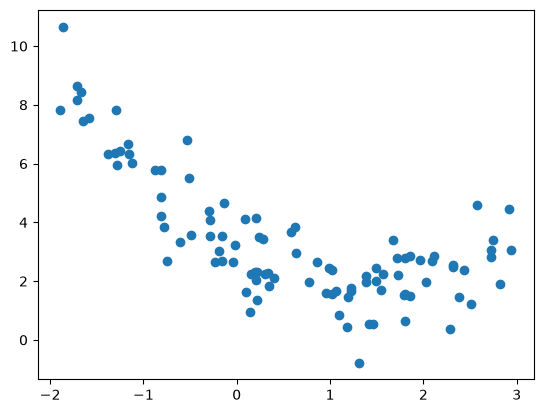

In [1]:
m = 100
X = 5 * np.random.rand(m,1) - 2
Y = 0.7 * X ** 2 - 2 * X + 3 + np.random.randn(m,1)
plt.scatter(X,Y)
plt.show()

In [3]:
X_train,X_test,Y_train,Y_test = train(X.reshape(100,1),Y.reshape(100),0.2,2)

In [4]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=10)
X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

In [ ]:
from mlxtend.evaluate import bias_variance_decomp
alphas = np.linspace(0,30,100)
loss = []
bias = []
variance = []
for i in alphas:
    if i == 0:
        reg = LinearRegression()
    else:
        reg = Lasso(alpha=i,max_iter=50000)
    avg_expected_loss,avg_bias,avg_variance = bias_variance_decomp(reg,X_train,Y_train,X_test,Y_test,loss='mse',random_seed=123)
    loss.append(avg_expected_loss)
    bias.append(avg_bias)
    variance.append(avg_variance)

In [ ]:
plt.plot(alphas,loss,label='loss')
plt.plot(alphas,bias,label='bias')
plt.plot(alphas,variance,label='variance')
plt.xlabel('Alpha')
plt.legend()

#### Q4.Effect Of Regularization On Loss Function

[27.82809103]
-2.29474455867698


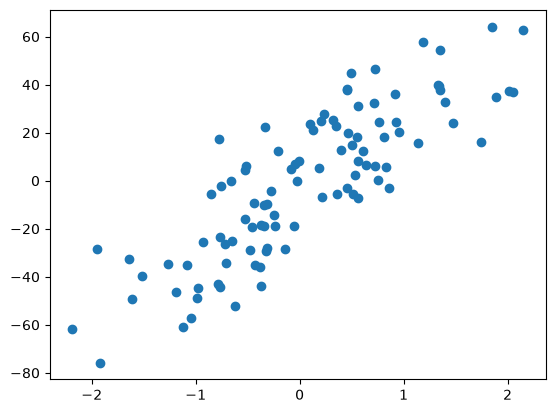

In [1]:
from sklearn.datasets import make_regression
X,Y = make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20,random_state=13)
plt.scatter(X,Y)
lr = LinearRegression()
lr.fit(X,Y)
print(lr.coef_)
print(lr.intercept_)

In [2]:
def cal_loss(m,alpha):
    return np.sum((Y - m * X.ravel() + 2.29) ** 2) + alpha * abs(m)

In [3]:
def predict(m):
    return m * X + 2.29

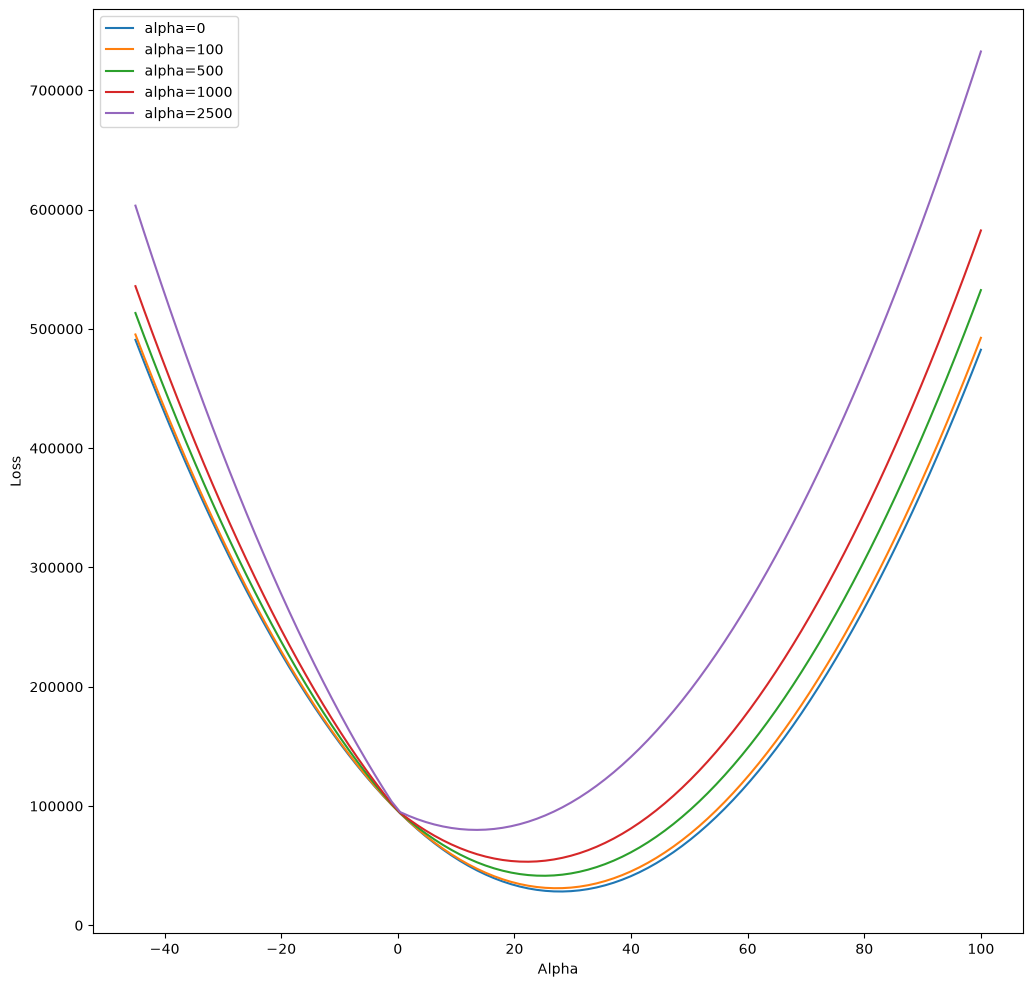

In [5]:
m = np.linspace(-45,100,100)
plt.figure(figsize=(12,12))
for j in [0,100,500,1000,2500]:
    loss = []
    for i in range(m.shape[0]):
        loss_i = cal_loss(m[i],j)
        loss.append(loss_i)
    plt.plot(m,loss,label='alpha={}'.format(j))
plt.legend()
plt.xlabel('Alpha')
plt.ylabel('Loss')
plt.show()

### Sparsity In Lasso Regresssion